===== DATA PREVIEW =====
  Gender     Height      Weight
0   Male  73.847017  241.893563
1   Male  68.781904  162.310473
2   Male  74.110105  212.740856
3   Male  71.730978  220.042470
4   Male  69.881796  206.349801

===== MISSING VALUES =====
Gender    0
Height    0
Weight    0
dtype: int64

After Handling Missing Values:
Gender    0
Height    0
Weight    0
dtype: int64

===== DATA TYPES =====
Gender     object
Height    float64
Weight    float64
dtype: object

Unique values in categorical columns:
Gender : ['male' 'female']

===== OUTLIER DETECTION =====


C:\Users\Subhi Jain\AppData\Local\Temp\ipykernel_25584\1589274425.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\Subhi Jain\AppData\Local\Temp\ipykernel_25584\1589274425.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

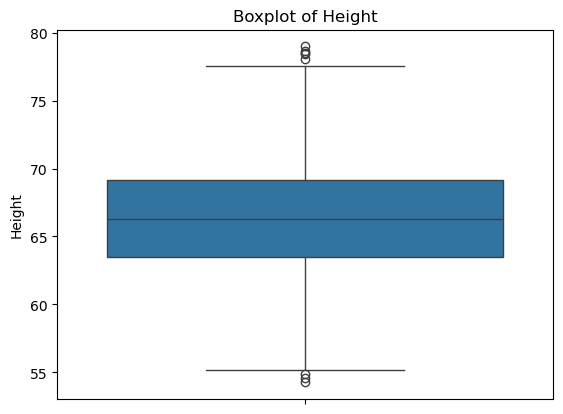

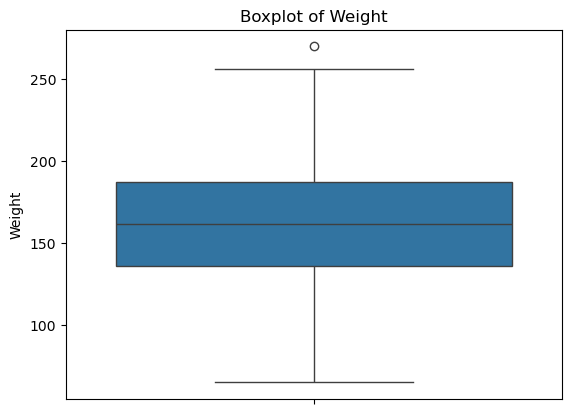


Outliers handled using IQR method.

Standardization Applied.
Log Transformation Applied where applicable.

===== FINAL DATASET =====
  Gender    Height    Weight
0   male  1.945003  2.505964
1   male  0.627894  0.027120
2   male  2.013415  1.597919
3   male  1.394758  1.825349
4   male  0.913905  1.398851


In [1]:
# ==========================================
# DATA WRANGLING - weight-height dataset
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------
# STEP 1: LOAD DATASET
# ------------------------------------------
df = pd.read_csv(r"C:\Users\Subhi Jain\Desktop\dsbda-prac_227\datasets\weight-height.csv")

print("===== DATA PREVIEW =====")
print(df.head())

# ------------------------------------------
# STEP 2: CHECK MISSING VALUES
# ------------------------------------------
print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

# Handle missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].mean(), inplace=True)

print("\nAfter Handling Missing Values:")
print(df.isnull().sum())

# ------------------------------------------
# STEP 3: CHECK INCONSISTENCIES
# ------------------------------------------
print("\n===== DATA TYPES =====")
print(df.dtypes)

# Fix categorical inconsistencies
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

print("\nUnique values in categorical columns:")
for col in df.select_dtypes(include='object').columns:
    print(col, ":", df[col].unique())

# ------------------------------------------
# STEP 4: OUTLIER DETECTION
# ------------------------------------------
numeric_cols = df.select_dtypes(include=np.number).columns

print("\n===== OUTLIER DETECTION =====")

for col in numeric_cols:
    plt.figure()
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# ------------------------------------------
# STEP 5: HANDLE OUTLIERS (IQR METHOD)
# ------------------------------------------
def cap_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return np.clip(column, lower, upper)

for col in numeric_cols:
    df[col] = cap_outliers(df[col])

print("\nOutliers handled using IQR method.")

# ------------------------------------------
# STEP 6: DATA TRANSFORMATION
# ------------------------------------------

# (A) Standardization (Change Scale)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("\nStandardization Applied.")

# (B) Log Transformation (Reduce Skewness)
for col in numeric_cols:
    if (df[col] > 0).all():
        df[col + "_log"] = np.log(df[col])

print("Log Transformation Applied where applicable.")

# ------------------------------------------
# FINAL OUTPUT
# ------------------------------------------
print("\n===== FINAL DATASET =====")
print(df.head())